# 04. Correlation Analysis
## Structural Health Monitoring — Heritage Masonry Vaults

**Purpose:** Evaluate the statistical relationship between structural displacements and
environmental variables (temperature, humidity, atmospheric pressure) using Pearson correlation.
Determine whether observed displacements follow a predictable elastic pattern or show
anomalous influences.

**Input:** `../data/processed/raw_unified.csv` — unified clean dataset from `02_data_cleaning.ipynb`

**Output:**
- `../outputs/tables/04_correlation_matrix_zone_a.png`
- `../outputs/tables/04_correlation_matrix_zone_b.png`
- `../outputs/tables/04_correlation_matrix_zone_c.png`
- `../outputs/tables/04_correlation_matrix_diagonal_sensors.png`
- `../outputs/tables/04_correlation_matrix_horizontal_sensors.png`
- `../outputs/tables/04_temporal_vs_temperature_diagonal.png`
- `../outputs/tables/04_temporal_vs_temperature_horizontal.png`
- `../outputs/tables/04_temporal_vs_humidity_diagonal.png`
- `../outputs/tables/04_temporal_vs_humidity_horizontal.png`
- `../outputs/tables/04_temporal_vs_pressure_diagonal.png`
- `../outputs/tables/04_temporal_vs_pressure_horizontal.png`
- `../outputs/tables/04_correlation_summary.xlsx`

**Next notebook:** `05_sensor_individual_analysis.ipynb`

---
### Interpretation Framework (Pearson r)

| r value | Interpretation |
|---------|----------------|
| r > +0.7 | Strong positive — displacement increases with variable |
| +0.3 to +0.7 | Moderate positive |
| -0.3 to +0.3 | No meaningful linear relationship |
| -0.3 to -0.7 | Moderate negative |
| r < -0.7 | Strong negative — displacement decreases as variable increases |

**Expected physical behavior:**
- **Temperature:** strong positive correlation (thermal expansion)
- **Humidity:** moderate negative correlation (inverse of temperature cycle — statistical artifact, not mechanical)
- **Pressure:** near zero (no mechanical effect on rigid masonry structures)

---
## 0. Configuration

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

# ============================================================
# ZONE AND SENSOR CONFIGURATION
# ============================================================
ZONES = {
    'Zone A': {
        'sensors'     : ['S01', 'S02', 'S03', 'S04'],
        'orientations': ['Diag.', 'Hor.', 'Diag.', 'Hor.']
    },
    'Zone B': {
        'sensors'     : ['S05', 'S06', 'S07', 'S08'],
        'orientations': ['Diag.', 'Hor.', 'Diag.', 'Hor.']
    },
    'Zone C': {
        'sensors'     : ['S09', 'S10', 'S11', 'S12'],
        'orientations': ['Diag.', 'Hor.', 'Diag.', 'Hor.']
    }
}

# Diagonal sensors (odd) = arch deformation
# Horizontal sensors (even) = lateral wall spread
DIAGONAL_SENSORS   = ['S01', 'S03', 'S05', 'S07', 'S09', 'S11']
HORIZONTAL_SENSORS = ['S02', 'S04', 'S06', 'S08', 'S10', 'S12']

ENV_VARS = {
    'Temp.': {'name': 'Temperature', 'unit': '°C',  'color': '#FF0000', 'range': (0, 40)},
    'Hum.':  {'name': 'Humidity',    'unit': '%',   'color': '#0047AB', 'range': (0, 100)},
    'Pres.': {'name': 'Pressure',    'unit': 'hPa', 'color': '#00AA00', 'range': (950, 1050)}
}

# Custom colormap: navy blue (negative) → white (zero) → crimson (positive)
CORR_CMAP = ['#001F3F', '#FFFFFF', '#C41E3A']

# Semi-pastel colors for sensor lines in overlay plots
SENSOR_COLORS = ['#5DADE2', '#F8A955', '#52BE80', '#EC7063', '#AF7AC5', '#F5B7B1']

# ============================================================
# PATHS
# ============================================================
PROCESSED_DATA_PATH = '../data/processed/'
TABLES_PATH         = '../outputs/tables/'
os.makedirs(TABLES_PATH, exist_ok=True)

print('Configuration loaded.')
print(f'Zones: {list(ZONES.keys())}')
print(f'Diagonal sensors: {DIAGONAL_SENSORS}')
print(f'Horizontal sensors: {HORIZONTAL_SENSORS}')

Configuration loaded.
Zones: ['Zone A', 'Zone B', 'Zone C']
Diagonal sensors: ['S01', 'S03', 'S05', 'S07', 'S09', 'S11']
Horizontal sensors: ['S02', 'S04', 'S06', 'S08', 'S10', 'S12']


---
## 1. Load Clean Unified Dataset

In [2]:
# ============================================================
# LOAD CLEAN UNIFIED DATASET
# Uses raw_unified.csv which contains all sensors and
# environmental variables in a single merged DataFrame.
# Note: individual sensor cleaning is already applied via
# the per-sensor CSVs — this file retains all records for
# cross-sensor correlation computation.
# ============================================================
df_limpio = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'raw_unified.csv'))
df_limpio['Timestamp'] = pd.to_datetime(df_limpio['Timestamp'])

# Convert all sensor and environmental columns to numeric
all_sensors = DIAGONAL_SENSORS + HORIZONTAL_SENSORS
for col in all_sensors + list(ENV_VARS.keys()):
    if col in df_limpio.columns:
        df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce')

df_limpio.info()
print(f'\nDate range: {df_limpio["Timestamp"].min()} to {df_limpio["Timestamp"].max()}')
df_limpio.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 3463 entries, 0 to 3462
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Timestamp  3463 non-null   datetime64[us]
 1   S01        3363 non-null   float64       
 2   S02        3362 non-null   float64       
 3   S03        3179 non-null   float64       
 4   S04        3236 non-null   float64       
 5   S05        2386 non-null   float64       
 6   S06        2407 non-null   float64       
 7   S07        2829 non-null   float64       
 8   S08        2838 non-null   float64       
 9   S09        3418 non-null   float64       
 10  S10        3424 non-null   float64       
 11  S11        3421 non-null   float64       
 12  S12        3297 non-null   float64       
 13  Hum.       3425 non-null   float64       
 14  Pres.      3425 non-null   float64       
 15  Temp.      3425 non-null   float64       
dtypes: datetime64[us](1), float64(15)
memory usage: 433.0

,Timestamp,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,S11,S12,Hum.,Pres.,Temp.
0,2025-04-01 13:00:00,12633.00,24680.6,12754.00,24675.00,11883.71,24646.73,11247.00,24669.23,12633.12,24619.93,12413.92,24644.83,45.17,1013.69,28.37
1,2025-04-01 15:00:00,12632.06,24681.7,12753.80,24675.95,11882.20,24647.19,11247.79,24669.80,12631.62,24620.00,12413.78,24645.00,37.04,1011.57,33.41
2,2025-04-01 17:00:00,12633.50,24682.0,12751.91,24676.00,11880.25,24647.37,11248.00,24671.00,12628.79,24619.90,12411.04,24645.27,37.26,1010.26,31.13


---
## 2. Correlation Matrices — Per Structural Zone

Each zone's 4 sensors are correlated against each other and against the 3 environmental variables.
This reveals whether sensors within the same zone move as a mechanical unit
and which environmental variable drives the displacement.


CORRELATION ANALYSIS — ZONE A

Pearson r — Zone A sensors vs environmental variables:

  S01 vs Temperature   : r = +0.608  (Moderate positive)
  S01 vs Humidity      : r = -0.410  (Moderate negative)
  S01 vs Pressure      : r = -0.491  (Moderate negative)

  S02 vs Temperature   : r = +0.647  (Moderate positive)
  S02 vs Humidity      : r = -0.528  (Moderate negative)
  S02 vs Pressure      : r = -0.448  (Moderate negative)

  S03 vs Temperature   : r = -0.112  (No relationship)
  S03 vs Humidity      : r = -0.107  (No relationship)
  S03 vs Pressure      : r = +0.416  (Moderate positive)

  S04 vs Temperature   : r = +0.834  (Strong positive)
  S04 vs Humidity      : r = -0.676  (Moderate negative)
  S04 vs Pressure      : r = -0.524  (Moderate negative)

  Exported: 04_correlation_matrix_zone_a.png


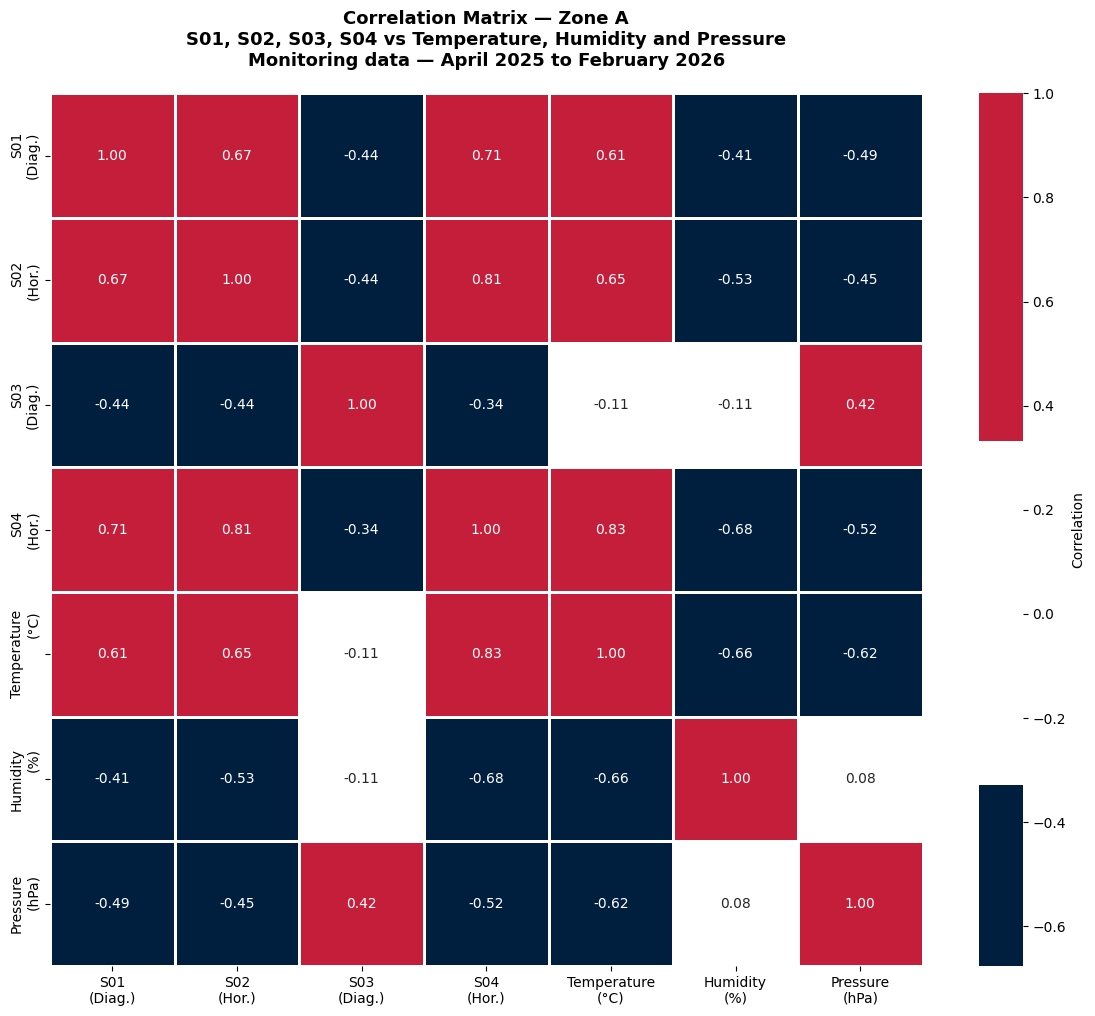


CORRELATION ANALYSIS — ZONE B

Pearson r — Zone B sensors vs environmental variables:

  S05 vs Temperature   : r = -0.390  (Moderate negative)
  S05 vs Humidity      : r = +0.148  (No relationship)
  S05 vs Pressure      : r = +0.362  (Moderate positive)

  S06 vs Temperature   : r = -0.514  (Moderate negative)
  S06 vs Humidity      : r = +0.147  (No relationship)
  S06 vs Pressure      : r = +0.439  (Moderate positive)

  S07 vs Temperature   : r = +0.801  (Strong positive)
  S07 vs Humidity      : r = -0.637  (Moderate negative)
  S07 vs Pressure      : r = -0.458  (Moderate negative)

  S08 vs Temperature   : r = +0.393  (Moderate positive)
  S08 vs Humidity      : r = -0.247  (No relationship)
  S08 vs Pressure      : r = -0.306  (Moderate negative)

  Exported: 04_correlation_matrix_zone_b.png


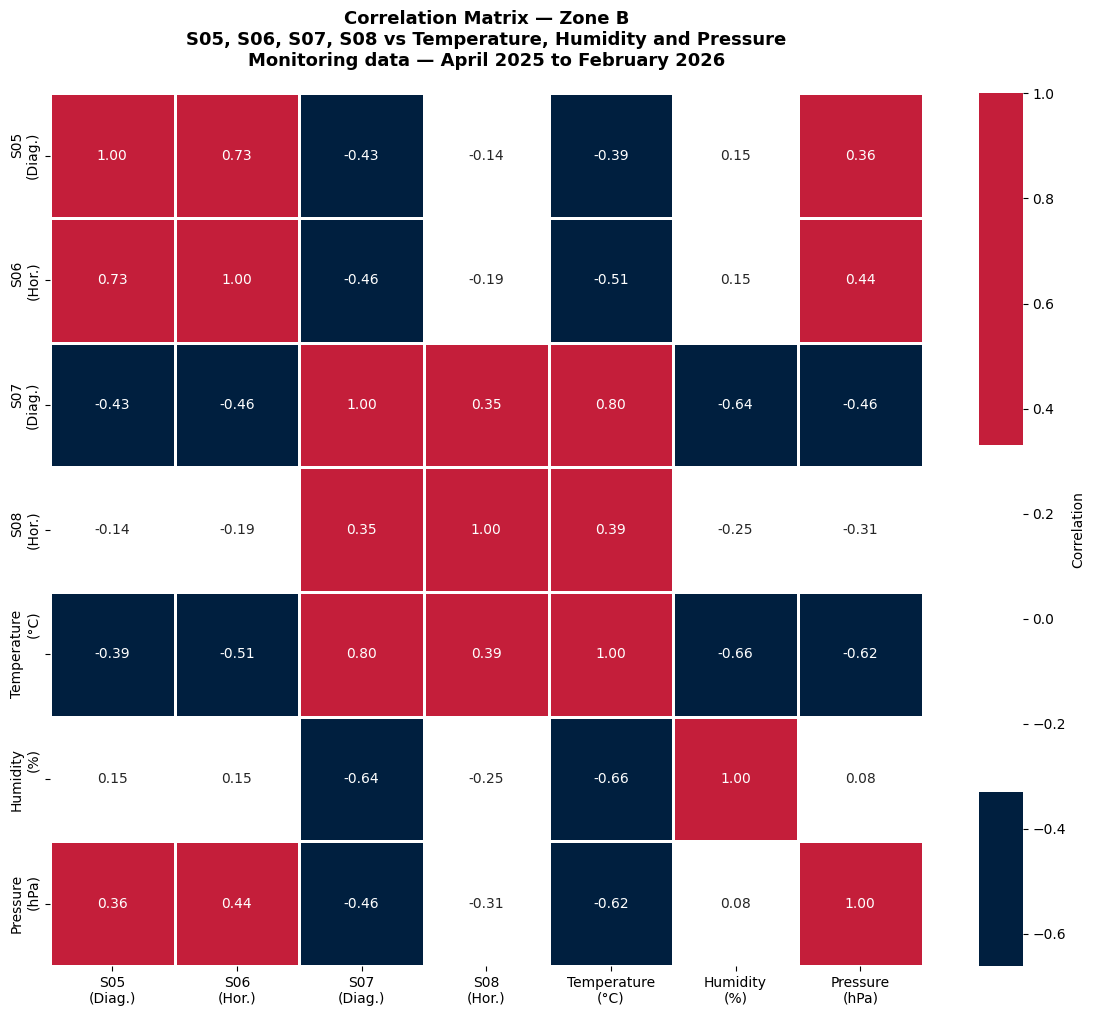


CORRELATION ANALYSIS — ZONE C

Pearson r — Zone C sensors vs environmental variables:

  S09 vs Temperature   : r = -0.328  (Moderate negative)
  S09 vs Humidity      : r = +0.337  (Moderate positive)
  S09 vs Pressure      : r = +0.209  (No relationship)

  S10 vs Temperature   : r = +0.548  (Moderate positive)
  S10 vs Humidity      : r = -0.632  (Moderate negative)
  S10 vs Pressure      : r = -0.286  (No relationship)

  S11 vs Temperature   : r = +0.564  (Moderate positive)
  S11 vs Humidity      : r = -0.470  (Moderate negative)
  S11 vs Pressure      : r = -0.095  (No relationship)

  S12 vs Temperature   : r = +0.084  (No relationship)
  S12 vs Humidity      : r = -0.002  (No relationship)
  S12 vs Pressure      : r = -0.122  (No relationship)

  Exported: 04_correlation_matrix_zone_c.png


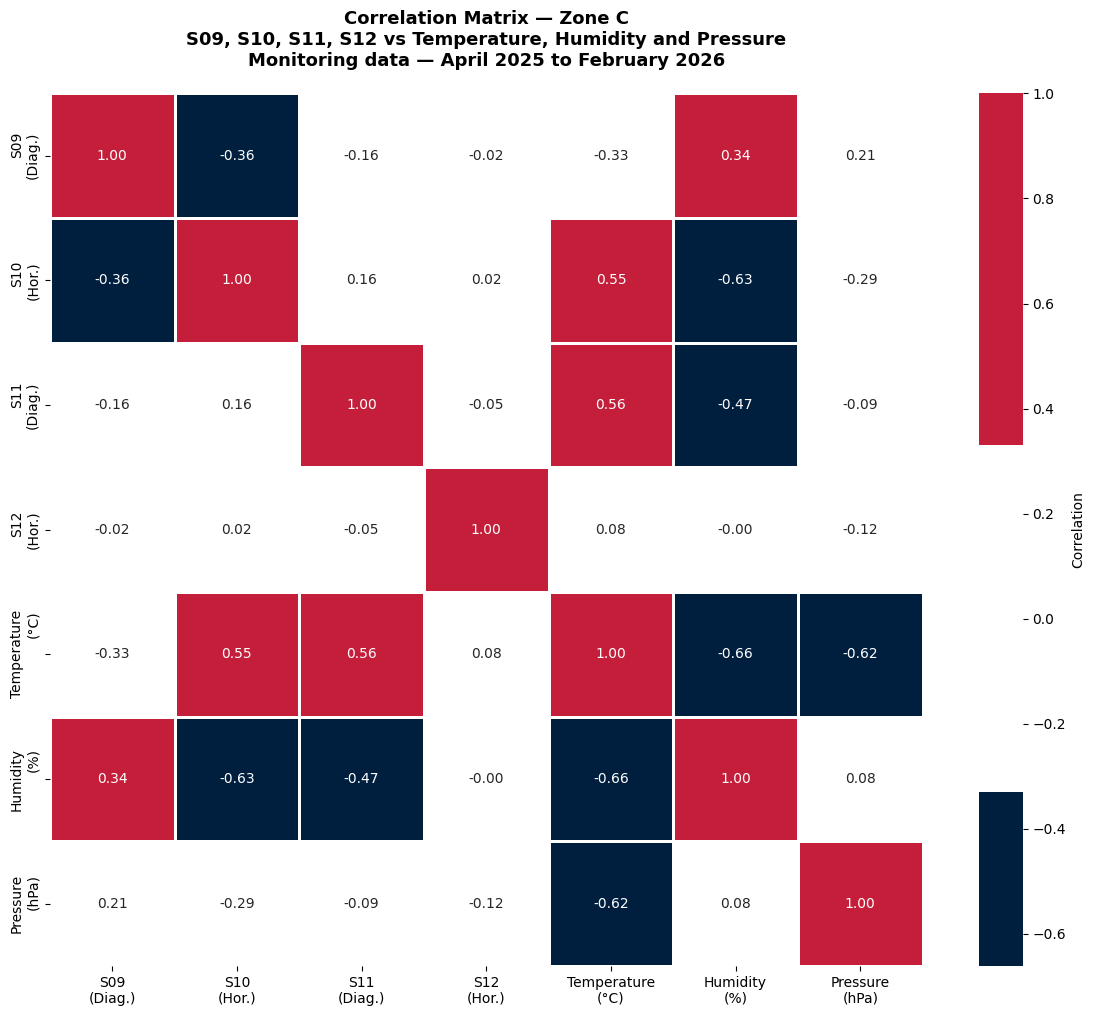

In [3]:
# ============================================================
# CORRELATION MATRICES PER ZONE
# ============================================================
def plot_zone_correlation(df, zone_name, sensors, orientations):
    """
    Generates and saves a Pearson correlation heatmap for one structural zone.
    Includes zone sensors cross-correlated with environmental variables.
    """
    print(f"\n{'='*100}")
    print(f"CORRELATION ANALYSIS — {zone_name.upper()}")
    print(f"{'='*100}\n")

    # Build display labels with orientation on second line
    label_map = {s: f"{s}\n({o})" for s, o in zip(sensors, orientations)}
    label_map.update({
        'Temp.': 'Temperature\n(°C)',
        'Hum.' : 'Humidity\n(%)',
        'Pres.': 'Pressure\n(hPa)'
    })

    cols = sensors + list(ENV_VARS.keys())
    cols = [c for c in cols if c in df.columns]

    corr = df[cols].corr()
    corr_display = corr.rename(index=label_map, columns=label_map)

    # Print correlation values
    print(f"Pearson r — {zone_name} sensors vs environmental variables:\n")
    for sensor in sensors:
        if sensor not in df.columns:
            continue
        for var, info in ENV_VARS.items():
            r = corr.loc[sensor, var] if var in corr.columns else float('nan')
            interpretation = (
                'Strong positive'   if r > 0.7  else
                'Moderate positive' if r > 0.3  else
                'Strong negative'   if r < -0.7 else
                'Moderate negative' if r < -0.3 else
                'No relationship'
            )
            print(f"  {sensor} vs {info['name']:<14}: r = {r:+.3f}  ({interpretation})")
        print()

    # Heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_display, annot=True, fmt='.2f', cmap=CORR_CMAP,
                center=0, square=True, linewidths=2,
                cbar_kws={'label': 'Correlation'}, ax=ax)
    ax.set_title(
        f'Correlation Matrix — {zone_name}\n'
        f'{", ".join(sensors)} vs Temperature, Humidity and Pressure\n'
        f'Monitoring data — April 2025 to February 2026',
        fontsize=13, fontweight='bold', pad=20
    )
    plt.tight_layout()

    fname = f'04_correlation_matrix_{zone_name.lower().replace(" ", "_")}.png'
    plt.savefig(os.path.join(TABLES_PATH, fname), dpi=300, bbox_inches='tight')
    print(f'  Exported: {fname}')
    plt.show()

    return corr


# Run for all three zones
zone_correlations = {}
for zone_name, info in ZONES.items():
    zone_correlations[zone_name] = plot_zone_correlation(
        df_limpio, zone_name, info['sensors'], info['orientations']
    )

---
## 3. Correlation Matrices — By Axis Group

Cross-zone correlation grouped by measurement axis:
- **Diagonal sensors (S01, S03, S05, S07, S09, S11):** arch deformation
- **Horizontal sensors (S02, S04, S06, S08, S10, S12):** lateral wall spread

This reveals whether all horizontal sensors across zones respond similarly to temperature
(validating uniform thermal expansion behavior) vs diagonal sensors which may show
more zone-specific behavior depending on local structural stiffness.


CORRELATION — DIAGONAL SENSORS

Pearson r vs environmental variables:

  S01:  Temp=+0.608  Hum=-0.410  Pres=-0.491
  S03:  Temp=-0.112  Hum=-0.107  Pres=+0.416
  S05:  Temp=-0.390  Hum=+0.148  Pres=+0.362
  S07:  Temp=+0.801  Hum=-0.637  Pres=-0.458
  S09:  Temp=-0.328  Hum=+0.337  Pres=+0.209
  S11:  Temp=+0.564  Hum=-0.470  Pres=-0.095

  Exported: 04_correlation_matrix_diagonal_sensors.png


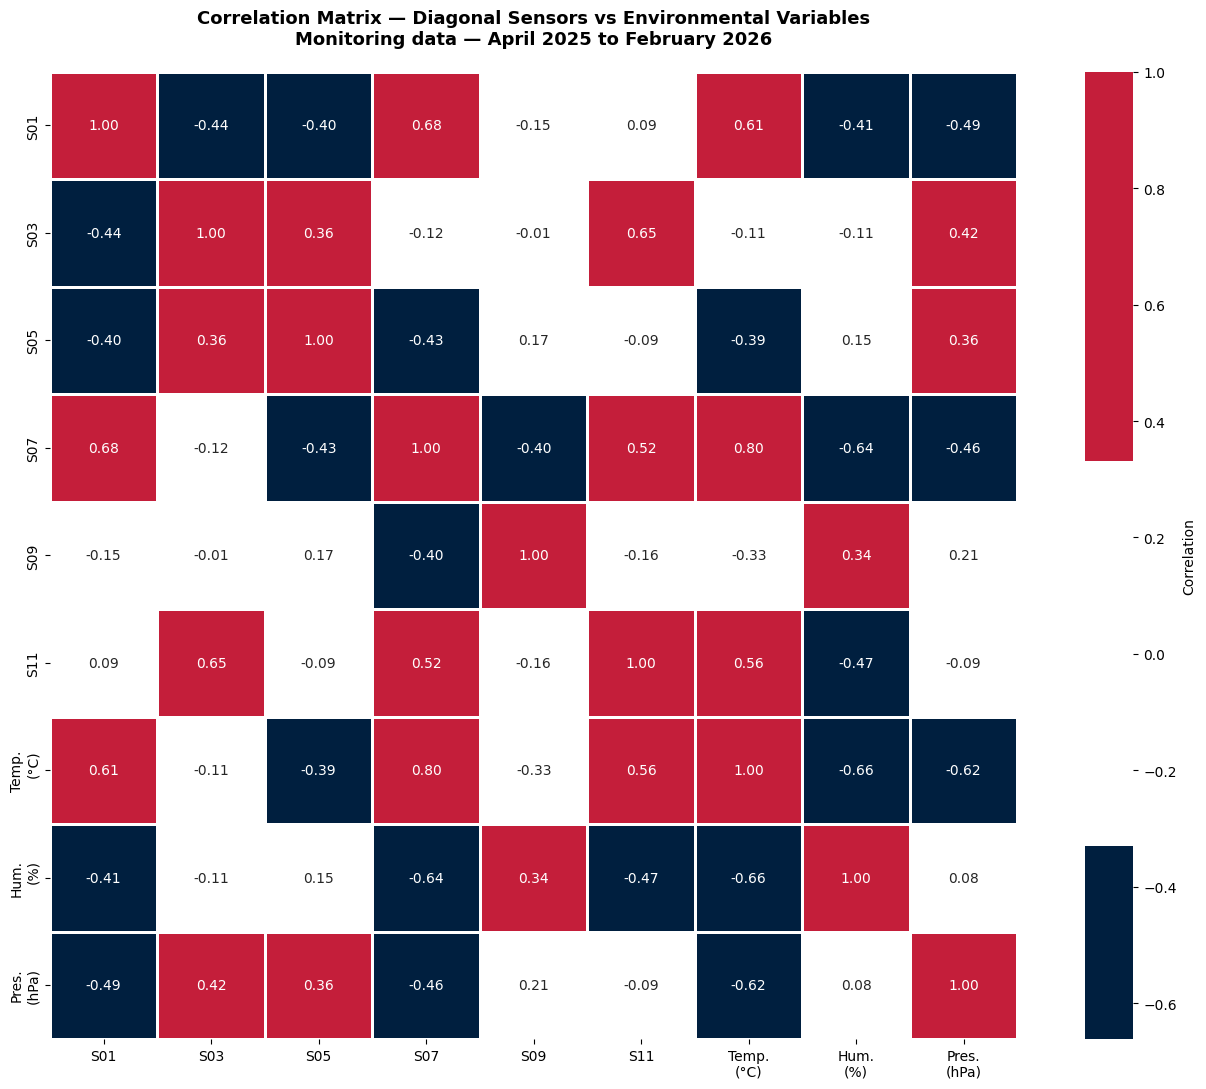


CORRELATION — HORIZONTAL SENSORS

Pearson r vs environmental variables:

  S02:  Temp=+0.647  Hum=-0.528  Pres=-0.448
  S04:  Temp=+0.834  Hum=-0.676  Pres=-0.524
  S06:  Temp=-0.514  Hum=+0.147  Pres=+0.439
  S08:  Temp=+0.393  Hum=-0.247  Pres=-0.306
  S10:  Temp=+0.548  Hum=-0.632  Pres=-0.286
  S12:  Temp=+0.084  Hum=-0.002  Pres=-0.122

  Exported: 04_correlation_matrix_horizontal_sensors.png


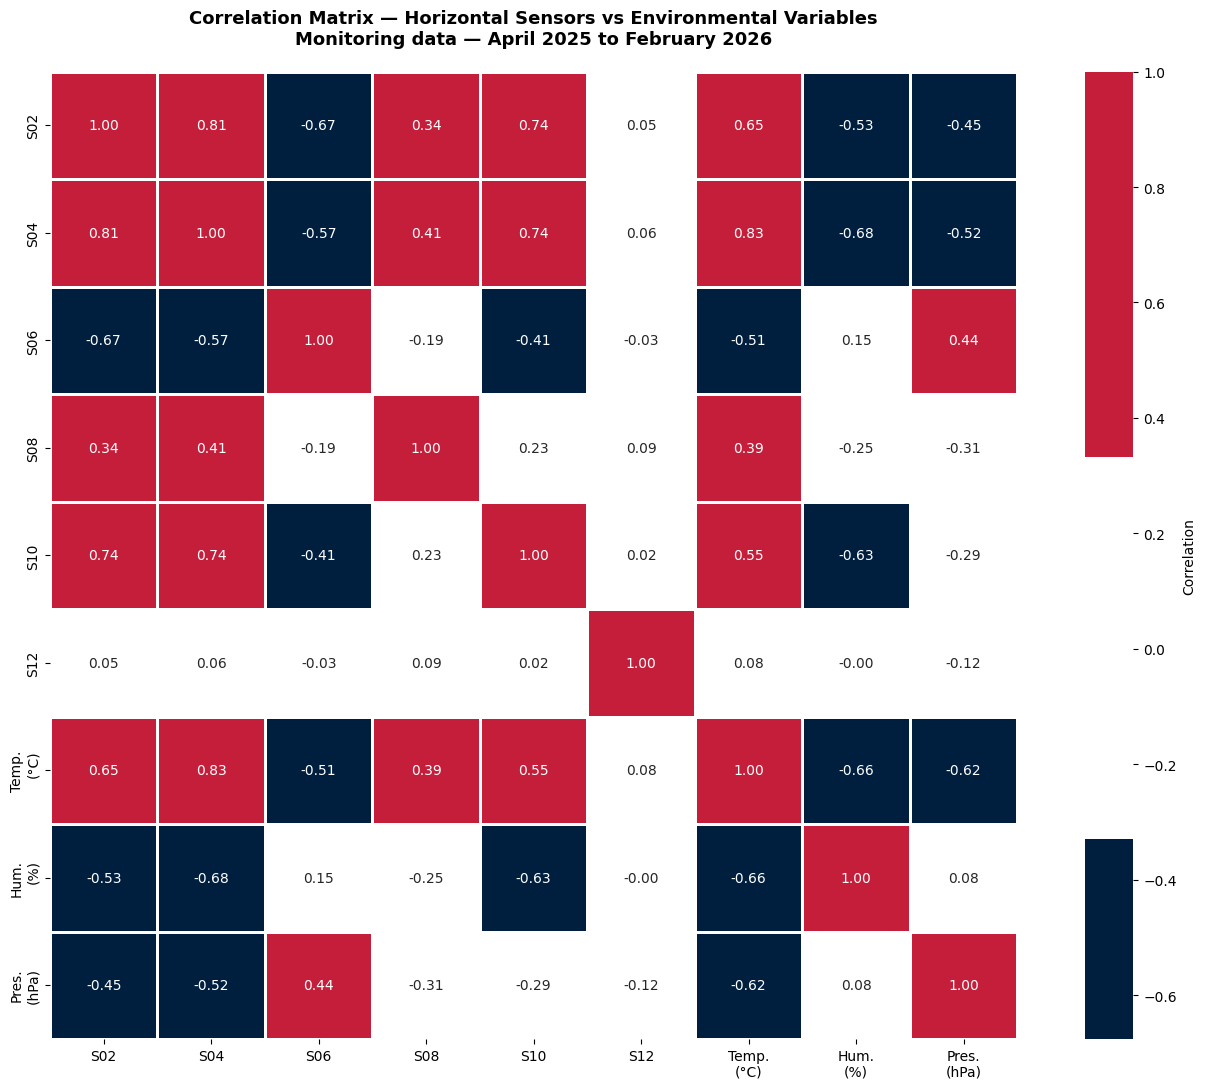

In [4]:
# ============================================================
# CORRELATION MATRICES BY AXIS GROUP
# Diagonal (odd) vs Horizontal (even) sensors
# ============================================================
def plot_axis_group_correlation(df, sensors, group_name):
    """
    Generates correlation heatmap for a group of sensors
    (all diagonal or all horizontal) vs environmental variables.
    """
    print(f"\n{'='*100}")
    print(f"CORRELATION — {group_name.upper()} SENSORS")
    print(f"{'='*100}\n")

    cols = [s for s in sensors if s in df.columns] + list(ENV_VARS.keys())
    corr = df[cols].corr()

    # Rename for display
    label_map = {
        'Temp.': 'Temp.\n(°C)',
        'Hum.' : 'Hum.\n(%)',
        'Pres.': 'Pres.\n(hPa)'
    }
    corr_display = corr.rename(index=label_map, columns=label_map)

    # Print r values vs environment
    print(f"Pearson r vs environmental variables:\n")
    for sensor in sensors:
        if sensor not in df.columns:
            continue
        r_temp = corr.loc[sensor, 'Temp.']
        r_hum  = corr.loc[sensor, 'Hum.']
        r_pres = corr.loc[sensor, 'Pres.']
        print(f"  {sensor}:  Temp={r_temp:+.3f}  Hum={r_hum:+.3f}  Pres={r_pres:+.3f}")

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(corr_display, annot=True, fmt='.2f', cmap=CORR_CMAP,
                center=0, square=True, linewidths=2,
                cbar_kws={'label': 'Correlation'}, ax=ax)
    ax.set_title(
        f'Correlation Matrix — {group_name} Sensors vs Environmental Variables\n'
        f'Monitoring data — April 2025 to February 2026',
        fontsize=13, fontweight='bold', pad=20
    )
    plt.tight_layout()

    fname = f'04_correlation_matrix_{group_name.lower()}_sensors.png'
    plt.savefig(os.path.join(TABLES_PATH, fname), dpi=300, bbox_inches='tight')
    print(f'\n  Exported: {fname}')
    plt.show()

    return corr


corr_diagonal   = plot_axis_group_correlation(df_limpio, DIAGONAL_SENSORS,   'Diagonal')
corr_horizontal = plot_axis_group_correlation(df_limpio, HORIZONTAL_SENSORS, 'Horizontal')

---
## 4. Temporal Overlay — Sensors vs Environmental Variables

Normalized temporal comparison: each sensor and environmental variable scaled to the same
range using MinMaxScaler, then overlaid to visually validate the Pearson correlations.

**Why normalize?** Sensors measure in mm (~12,000–25,000 mm absolute), temperature in °C,
humidity in %, pressure in hPa — all completely different scales. Normalization to a
common range (0–10) makes them visually comparable without altering the correlation structure.

This is a **visual validation step** — the overlay should confirm what the Pearson r values
indicate: displacement peaks coinciding with temperature peaks, inverse relationship with
humidity, independence from pressure.

In [5]:
# ============================================================
# TEMPORAL OVERLAY FUNCTION
# Normalizes sensors and one environmental variable to range
# matching the variable's physical units for interpretability.
# ============================================================
def plot_temporal_vs_env(df, sensors, group_name, var_key):
    """
    Plots normalized temporal overlay: sensor group vs one environmental variable.

    Parameters:
        df         : DataFrame with all sensors and environmental variables
        sensors    : list of sensor column names to plot
        group_name : 'Diagonal' or 'Horizontal' — for title and filename
        var_key    : environmental variable key ('Temp.', 'Hum.', or 'Pres.')
    """
    var_info  = ENV_VARS[var_key]
    var_range = var_info['range']

    df_norm = df.copy()

    # Normalize each sensor to the variable's physical range
    for sensor in sensors:
        if sensor in df_norm.columns:
            scaler = MinMaxScaler(feature_range=var_range)
            df_norm[sensor] = scaler.fit_transform(df[[sensor]])

    # Normalize environmental variable to its own range
    if var_key in df_norm.columns:
        scaler_var = MinMaxScaler(feature_range=var_range)
        df_norm[var_key] = scaler_var.fit_transform(
            df[[var_key]].fillna(df[var_key].mean()))

    fig, ax = plt.subplots(figsize=(40, 8))

    # Plot sensors
    for idx, sensor in enumerate(sensors):
        if sensor in df_norm.columns:
            ax.plot(df_norm['Timestamp'], df_norm[sensor],
                    label=sensor, linewidth=2,
                    color=SENSOR_COLORS[idx % len(SENSOR_COLORS)], alpha=0.85)

    # Plot environmental variable (bold, distinct color)
    ax.plot(df_norm['Timestamp'], df_norm[var_key],
            label=f'{var_info["name"]} ({var_info["unit"]})',
            linewidth=3, color=var_info['color'], alpha=0.9)

    ax.set_title(
        f'{var_info["name"]} vs {group_name} Sensors\n'
        f'Normalized to range {var_range[0]}–{var_range[1]} {var_info["unit"]}\n'
        f'Monitoring data — {df["Timestamp"].min().strftime("%d-%m-%Y")} '
        f'to {df["Timestamp"].max().strftime("%d-%m-%Y")}',
        fontsize=14, fontweight='bold'
    )
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Normalized Value ({var_info["unit"]})', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11, ncol=4)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fname = f'04_temporal_vs_{var_info["name"].lower()}_{group_name.lower()}.png'
    plt.savefig(os.path.join(TABLES_PATH, fname), dpi=300, bbox_inches='tight')
    print(f'Exported: {fname}')
    plt.show()

Generating temporal overlay plots...

Exported: 04_temporal_vs_temperature_diagonal.png


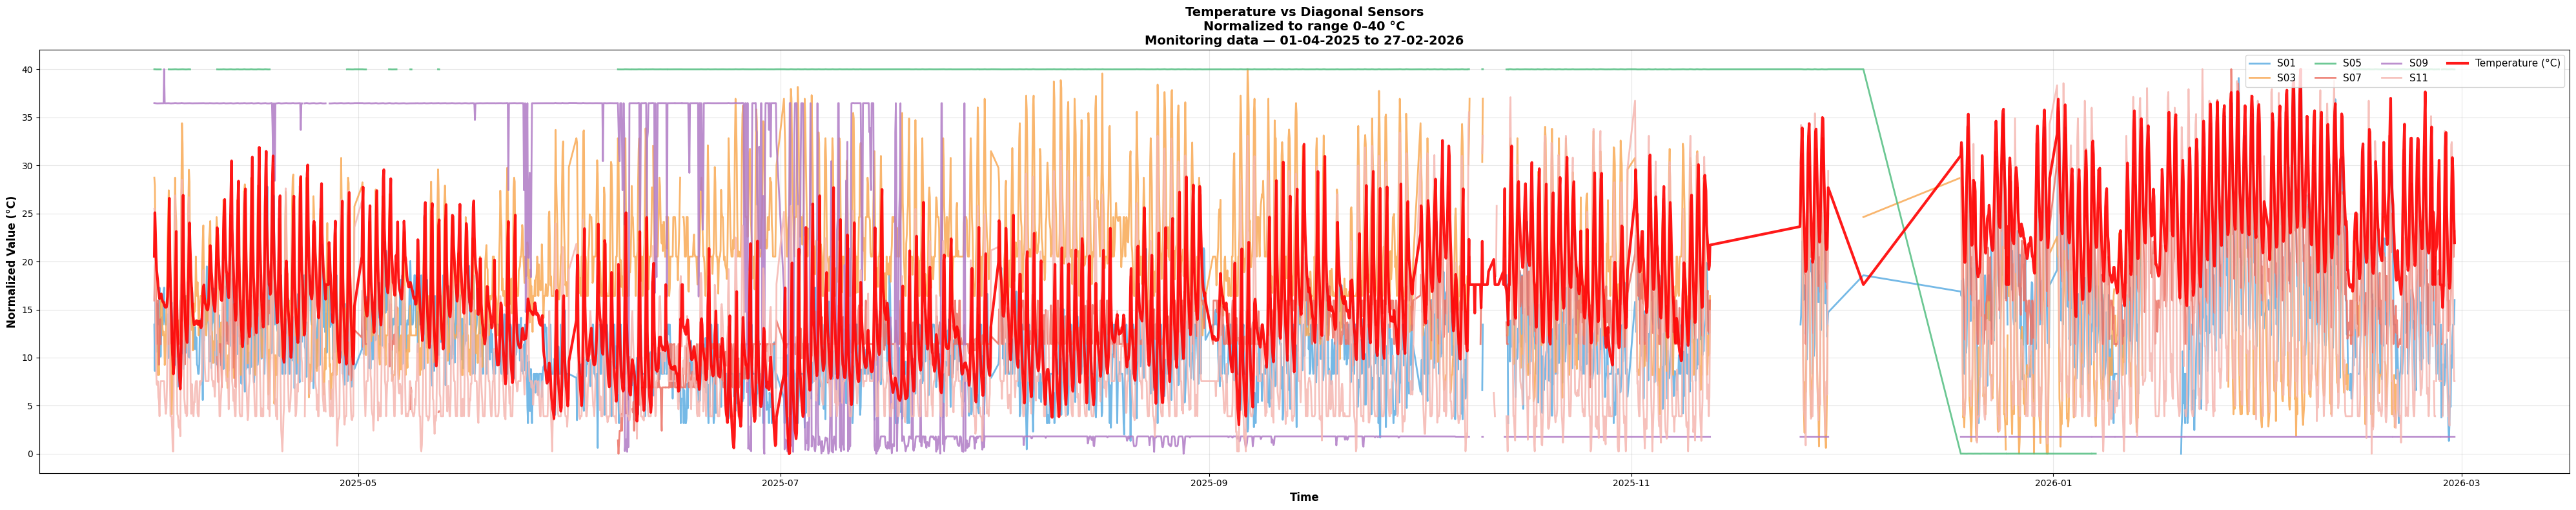

Exported: 04_temporal_vs_temperature_horizontal.png


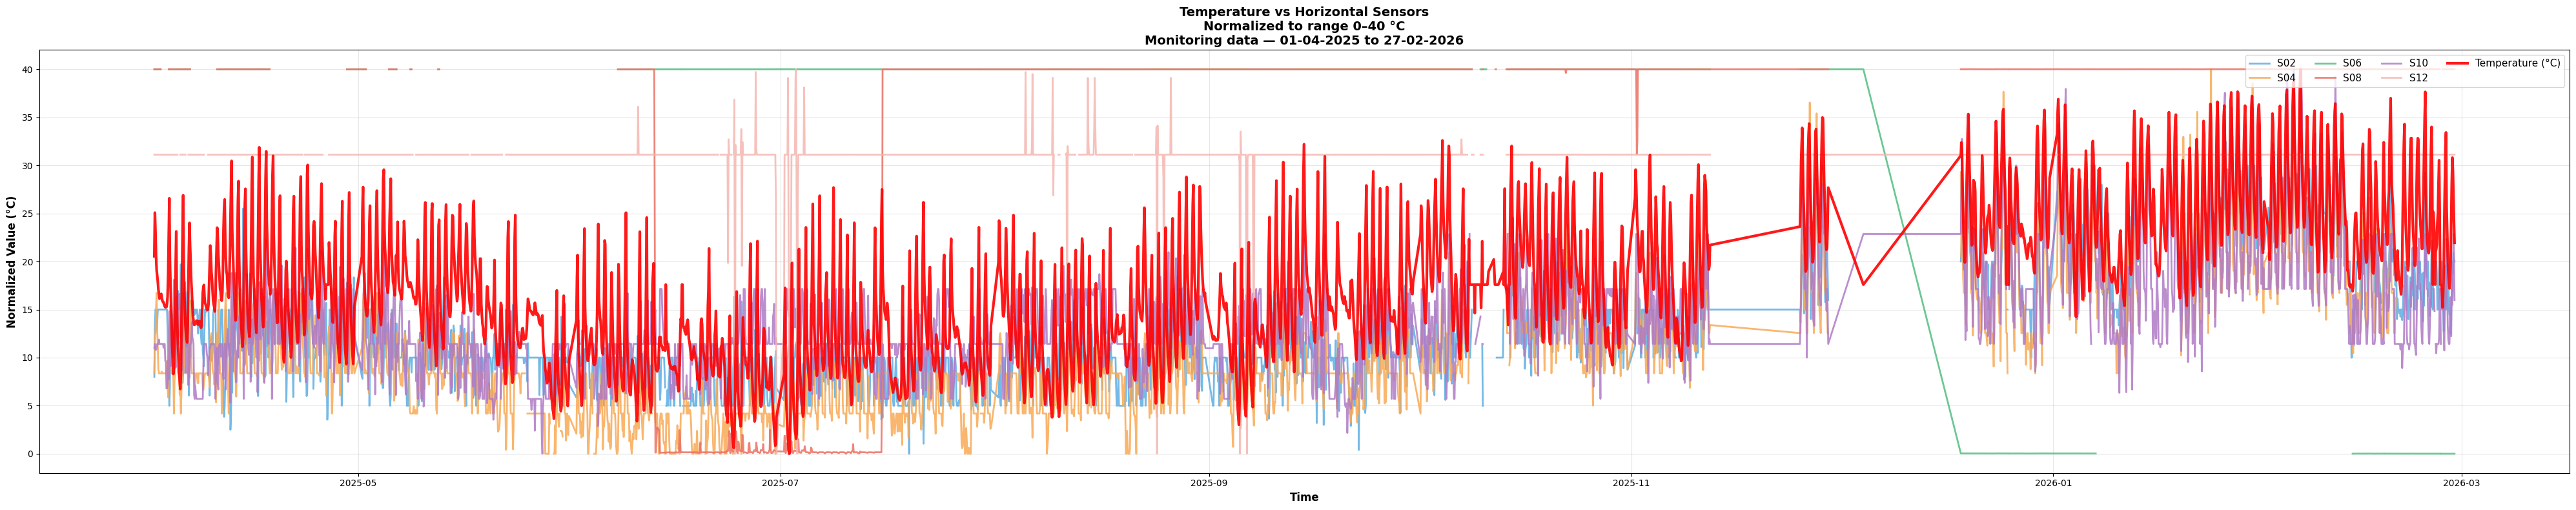

Exported: 04_temporal_vs_humidity_diagonal.png


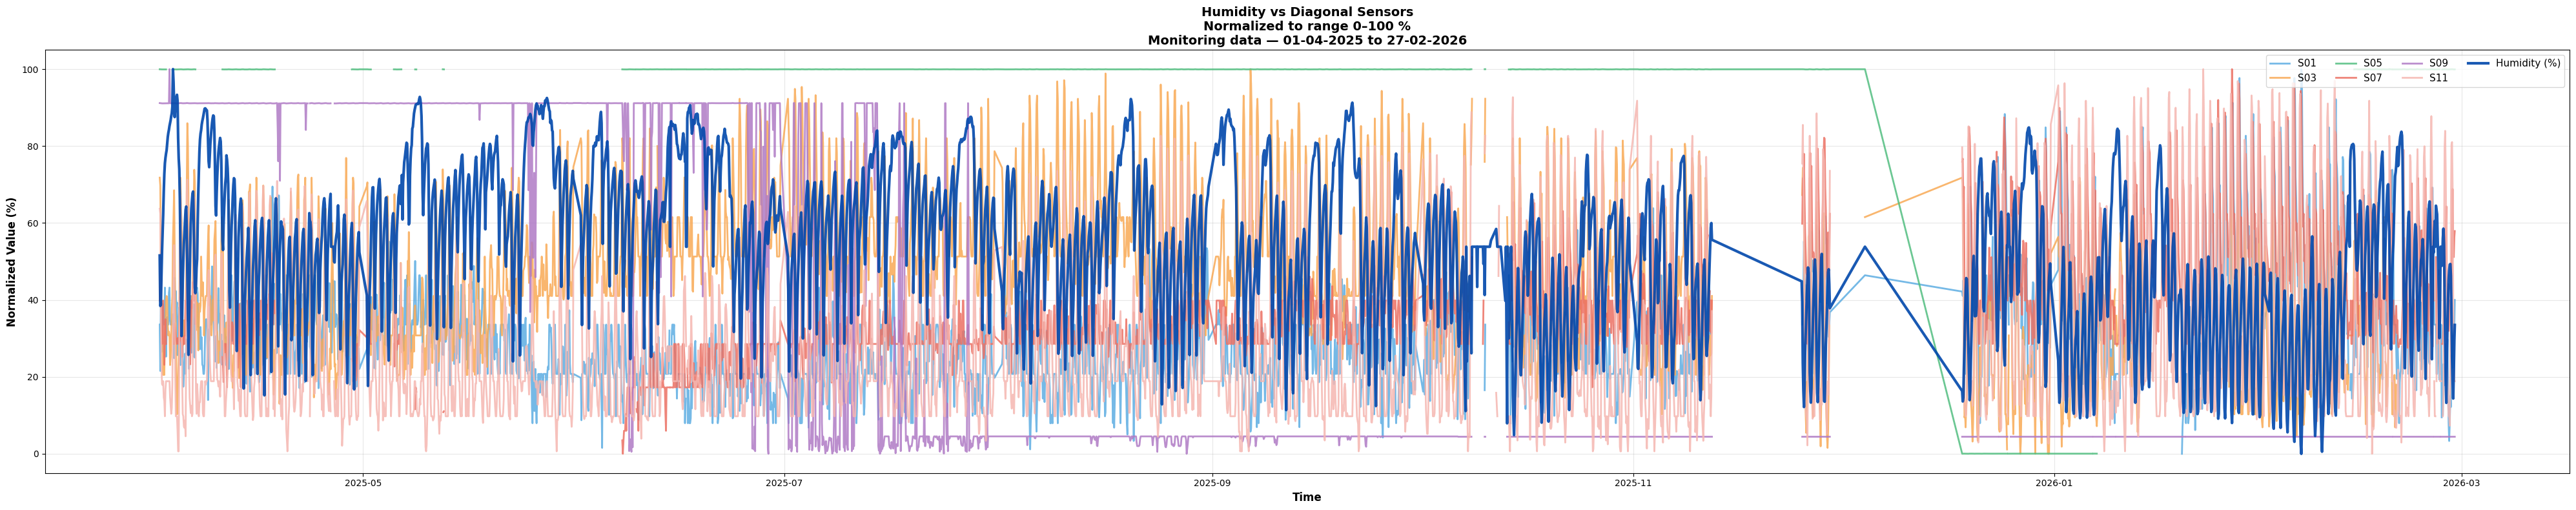

Exported: 04_temporal_vs_humidity_horizontal.png


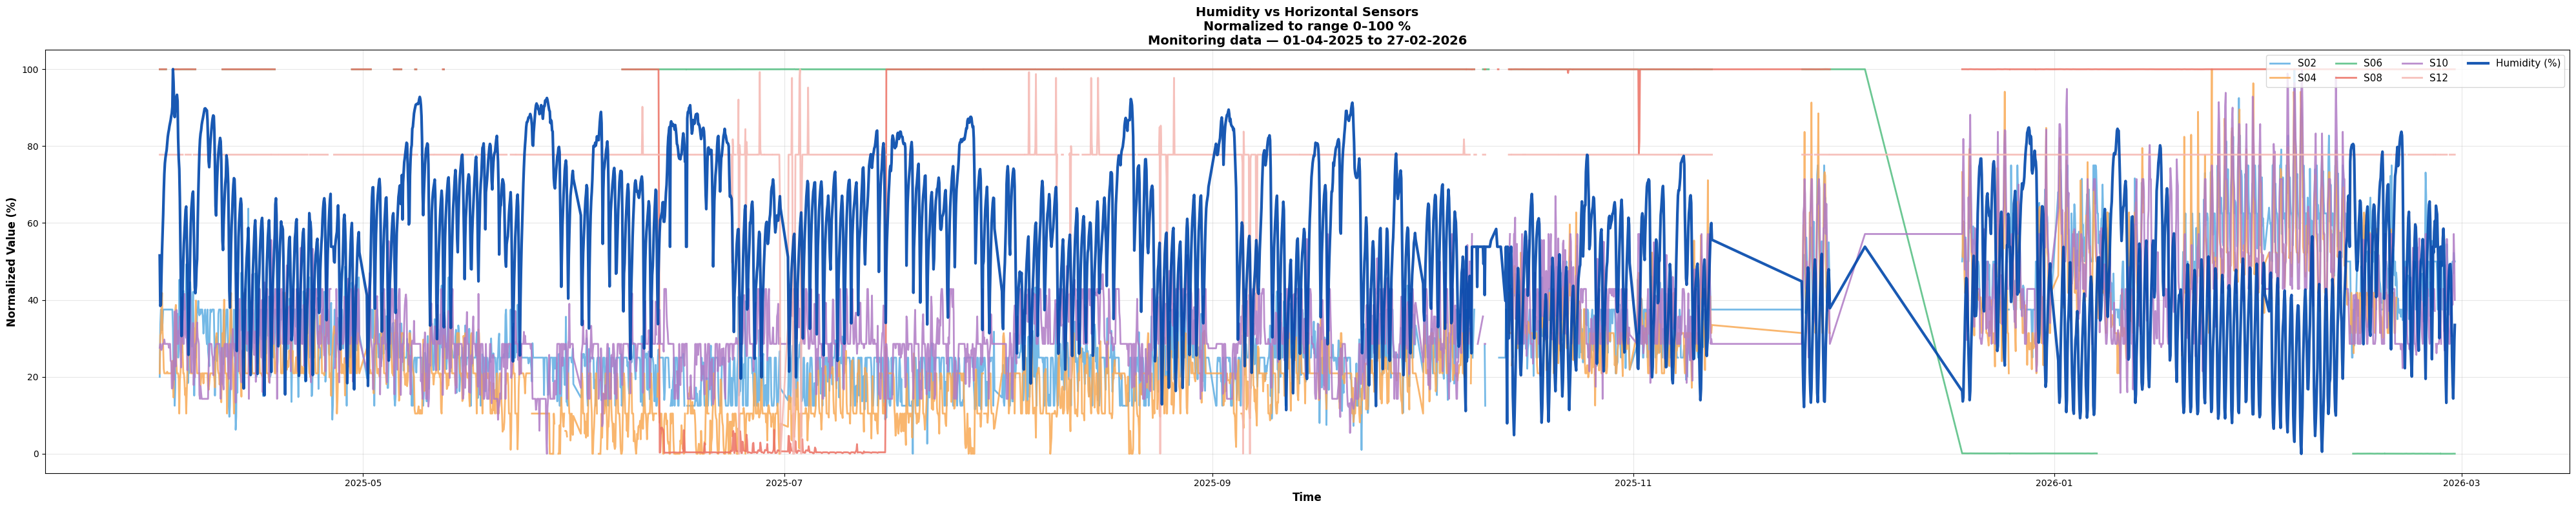

Exported: 04_temporal_vs_pressure_diagonal.png


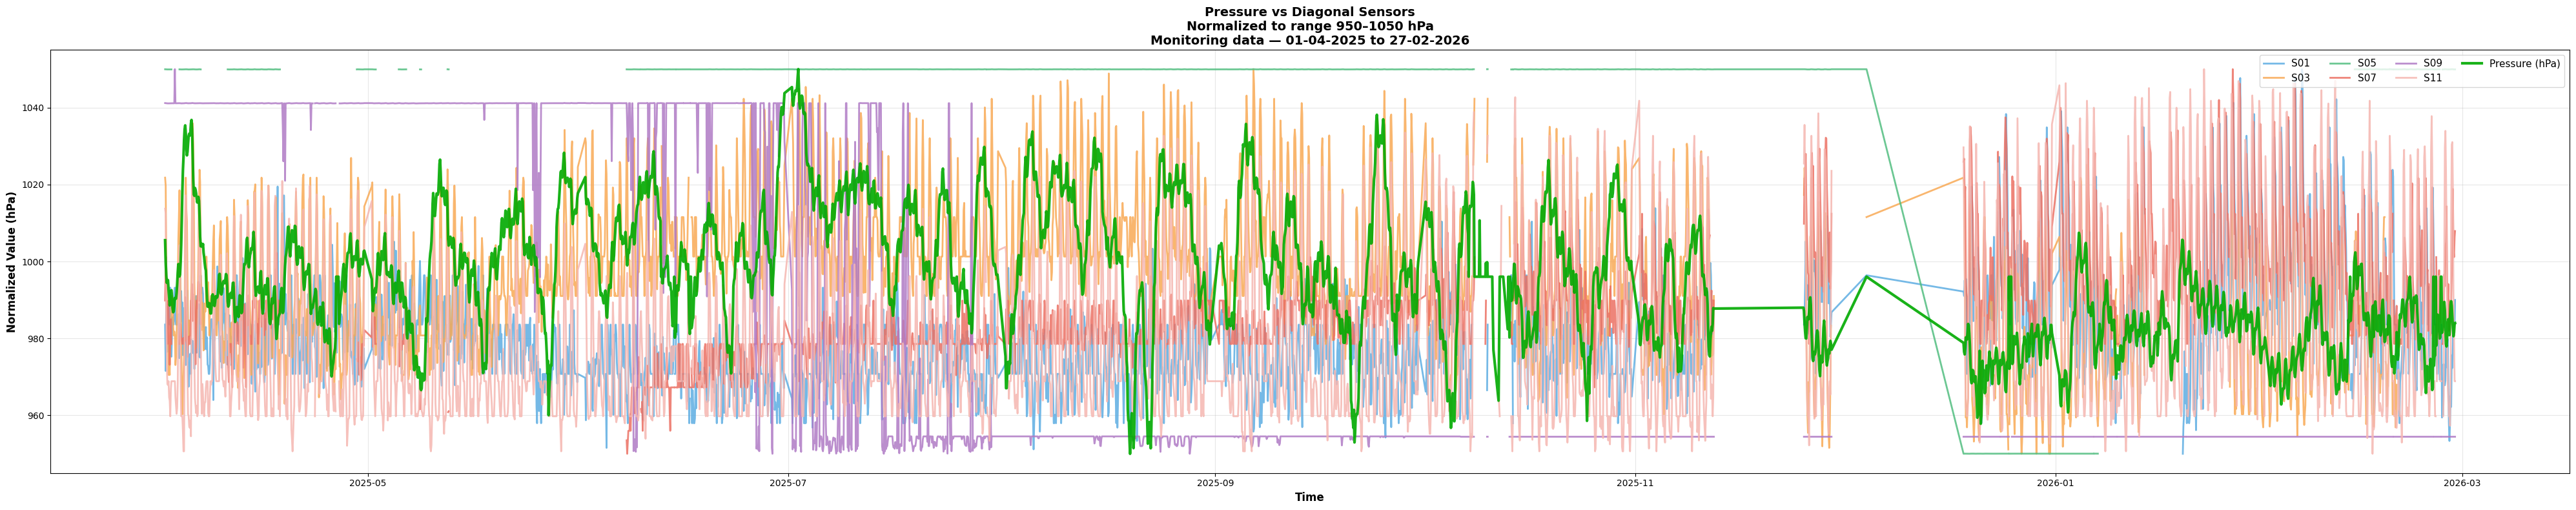

Exported: 04_temporal_vs_pressure_horizontal.png


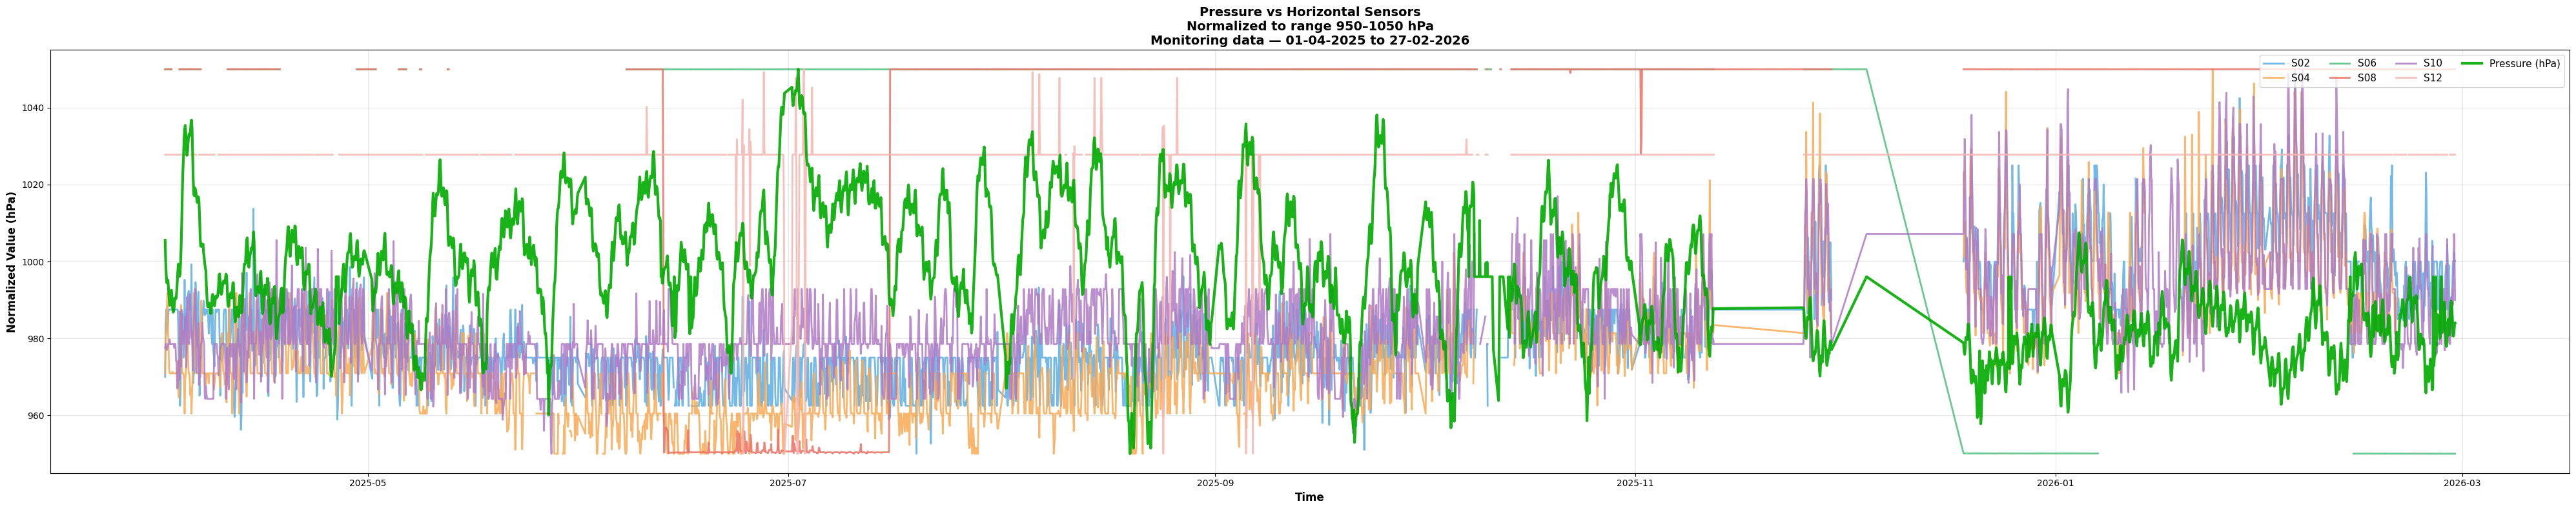


All temporal overlays generated.


In [6]:
# ============================================================
# RUN TEMPORAL OVERLAYS — ALL COMBINATIONS
# 3 environmental variables × 2 axis groups = 6 plots
# ============================================================
print('Generating temporal overlay plots...\n')

for var_key in ENV_VARS.keys():
    plot_temporal_vs_env(df_limpio, DIAGONAL_SENSORS,   'Diagonal',   var_key)
    plot_temporal_vs_env(df_limpio, HORIZONTAL_SENSORS, 'Horizontal', var_key)

print('\nAll temporal overlays generated.')

---
## 5. Correlation Summary Table

Consolidated table of Pearson r values for every sensor vs every environmental variable.
Used to support zone-level and system-level conclusions.

In [7]:
# ============================================================
# CORRELATION SUMMARY TABLE — ALL SENSORS vs ENV VARIABLES
# ============================================================
all_sensors_ordered = (
    ZONES['Zone A']['sensors'] +
    ZONES['Zone B']['sensors'] +
    ZONES['Zone C']['sensors']
)

summary_rows = []
for sensor in all_sensors_ordered:
    if sensor not in df_limpio.columns:
        continue

    # Determine zone and axis
    zone = next(z for z, info in ZONES.items() if sensor in info['sensors'])
    axis = ZONES[zone]['orientations'][ZONES[zone]['sensors'].index(sensor)]

    row = {'Sensor': sensor, 'Zone': zone, 'Axis': axis}

    for var_key, var_info in ENV_VARS.items():
        if var_key in df_limpio.columns:
            r = df_limpio[sensor].corr(df_limpio[var_key])
            row[f'r vs {var_info["name"]}'] = round(r, 2)
            # Interpretation
            interp = (
                'Strong+'   if r > 0.7  else
                'Moderate+' if r > 0.3  else
                'Strong-'   if r < -0.7 else
                'Moderate-' if r < -0.3 else
                'None'
            )
            row[f'{var_info["name"]} interpretation'] = interp

    summary_rows.append(row)

df_corr_summary = pd.DataFrame(summary_rows)

print(f"\n{'='*120}")
print(f"CORRELATION SUMMARY — ALL SENSORS vs ENVIRONMENTAL VARIABLES")
print(f"{'='*120}\n")
print(df_corr_summary.to_string(index=False))

out_path = os.path.join(TABLES_PATH, '04_correlation_summary.xlsx')
df_corr_summary.to_excel(out_path, index=False)
print(f'\nExported: {out_path}')


CORRELATION SUMMARY — ALL SENSORS vs ENVIRONMENTAL VARIABLES

Sensor   Zone  Axis  r vs Temperature Temperature interpretation  r vs Humidity Humidity interpretation  r vs Pressure Pressure interpretation
   S01 Zone A Diag.              0.61                  Moderate+          -0.41               Moderate-          -0.49               Moderate-
   S02 Zone A  Hor.              0.65                  Moderate+          -0.53               Moderate-          -0.45               Moderate-
   S03 Zone A Diag.             -0.11                       None          -0.11                    None           0.42               Moderate+
   S04 Zone A  Hor.              0.83                    Strong+          -0.68               Moderate-          -0.52               Moderate-
   S05 Zone B Diag.             -0.39                  Moderate-           0.15                    None           0.36               Moderate+
   S06 Zone B  Hor.             -0.51                  Moderate-           0.15

---
## Summary

This notebook produced:

| Output | Description |
|--------|-------------|
| `04_correlation_matrix_zone_a/b/c.png` | Per-zone Pearson correlation heatmaps |
| `04_correlation_matrix_diagonal_sensors.png` | Cross-zone diagonal group correlation |
| `04_correlation_matrix_horizontal_sensors.png` | Cross-zone horizontal group correlation |
| `04_temporal_vs_temperature/humidity/pressure_diagonal.png` | Normalized temporal overlays |
| `04_temporal_vs_temperature/humidity/pressure_horizontal.png` | Normalized temporal overlays |
| `04_correlation_summary.xlsx` | Full Pearson r table with interpretations |

**Key engineering interpretation of correlation results:**
- **Temperature (r = 0.7–0.9 on most sensors):** dominant driver — confirms thermally cyclic elastic behavior
- **Humidity (r = −0.3 to −0.7):** inverse of temperature cycle — statistical artifact, not hygroscopic mechanical response
- **Pressure (r ≈ 0):** no mechanical influence on rigid masonry — validates sensor stability

**Next:** `05_sensor_individual_analysis.ipynb` — parameterized per-sensor visual suite.